Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load Dataset

In [ ]:
df = pd.read_csv("insurance.csv")

## 3. Drop Region Column

In [ ]:
df = df.drop("region", axis=1)

## 4. Graphs (EDA)

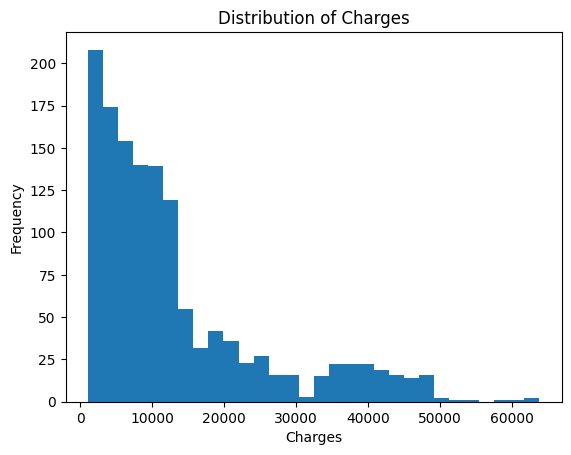

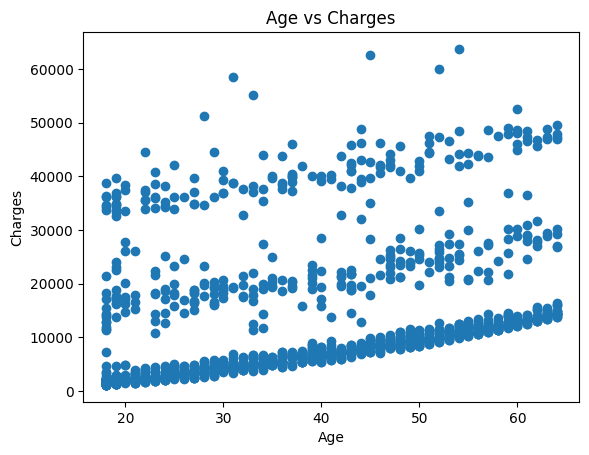

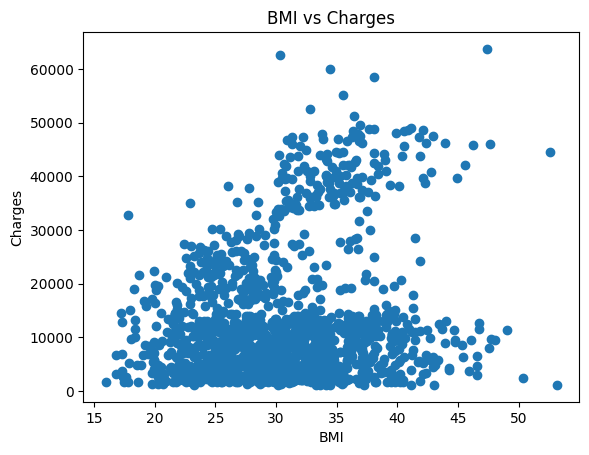

In [ ]:
plt.figure()
plt.hist(df['charges'], bins=30)
plt.title("Distribution of Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.scatter(df['age'], df['charges'])
plt.title("Age vs Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

plt.figure()
plt.scatter(df['bmi'], df['charges'])
plt.title("BMI vs Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

## 5. Preprocessing

In [ ]:
df = pd.get_dummies(df, drop_first=True)

X = df.drop("charges", axis=1)
y = df["charges"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 6. Models

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

## 7. Linear Regression Evaluation

Linear Regression RMSE: 5829.17293025419
Linear Regression R2 Score: 0.7811302113434095


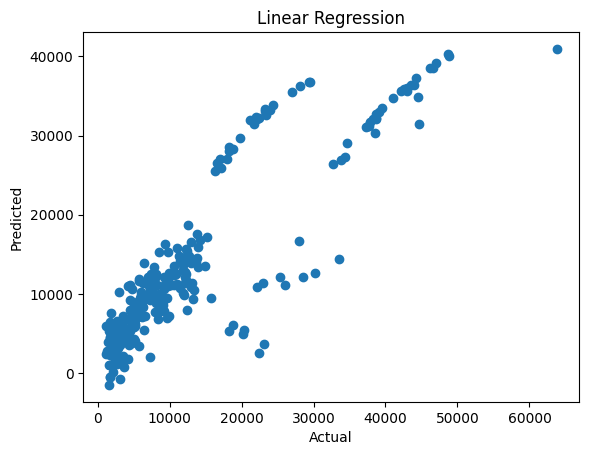

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R2 Score:", r2_lr)

plt.figure()
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression")
plt.show()

## 8. Random Forest Evaluation

Random Forest RMSE: 4696.586158725299
Random Forest R2 Score: 0.8579188291306657


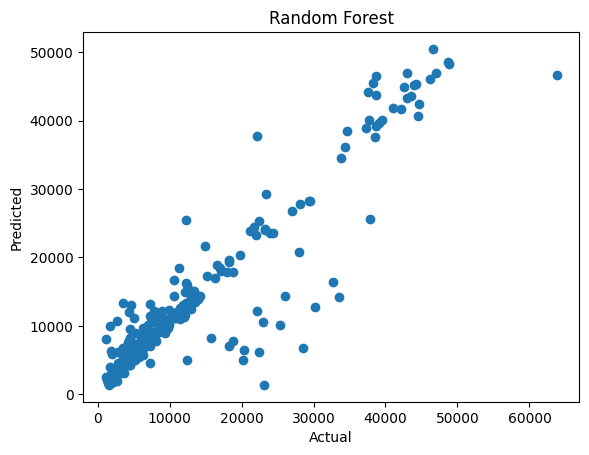

In [ ]:
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2 Score:", r2_rf)

plt.figure()
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest")
plt.show()

## 9. Feature Importance

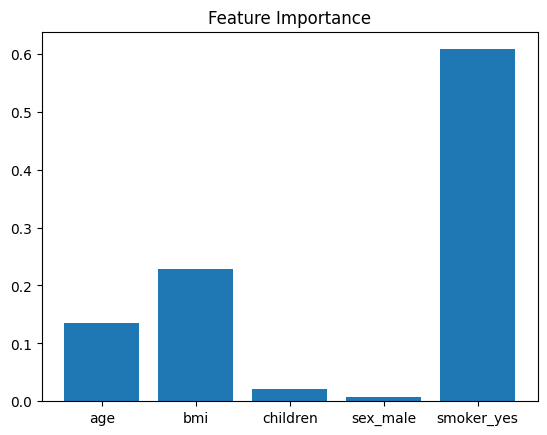

In [ ]:
importances = rf.feature_importances_
features = X.columns

plt.figure()
plt.bar(features, importances)
plt.title("Feature Importance")
plt.show()

## 10. User Input Prediction

In [ ]:
print("\nEnter Details:")

age = int(input("Age: "))
bmi = float(input("BMI: "))
children = int(input("Children: "))
sex = input("Sex (male/female): ").lower()
smoker = input("Smoker (yes/no): ").lower()

data = {
    'age': age,
    'bmi': bmi,
    'children': children,
    'sex_male': 1 if sex == 'male' else 0,
    'smoker_yes': 1 if smoker == 'yes' else 0
}

input_df = pd.DataFrame([data])
input_df = input_df.reindex(columns=X.columns, fill_value=0)

prediction = rf.predict(input_df)

print("\n💰 Predicted Insurance Cost:", prediction[0])


Enter Details:
Age: 56
BMI: 54
Children: 3
Sex (male/female): male
Smoker (yes/no): yes

💰 Predicted Insurance Cost: 49645.52698010001
